# Combat mission model — exploration notebook

This notebook **does not duplicate training code**. It imports `model.py` so metrics and behavior match `train.py` / deployment artifacts.

**Scope:** experiment with the trained scorer (GradientBoosting on evaluation history), inspect fit on the training matrix, and demo team selection.

**Team selection:** candidates are **mission-ranked** (top‑`k`). The API returns **`num_team_options`** (default **2**) **different six-person rosters**—each roster uses six **distinct** people, each anchoring a **different** ``task_group`` from the detailed rubric (Planning, Decisiveness, Attention to Detail, Tactics, Time Management, ST&EO). Options are **ranked by** the team heuristic score; **option 1** is also exposed as ``team`` / ``team_score`` / ``breakdown`` for backward compatibility. **`candidate_task_breakdowns`** lists **strengths** and **weaknesses** per pool member (top‑2 / bottom‑2 task groups by mean ``rating_score``).

**Not in scope here:** a separate “Athena” commander/coaching product; that layer would consume model outputs later.

**Caveats:** small sample (~100+ leader×event rows); profile features aggregate each leader’s full history while the target is the current event — treat as exploratory, not a rigorous generalization benchmark. Prefer temporal or leader-held-out validation before high-stakes use.

**Running:** after changing `model.py`, use **Restart** + **Run All**, or re-run the training cell before the team demo (it calls `importlib.reload(model)` so `select_team` stays in sync).

In [19]:
from __future__ import annotations

import os
import sys
from pathlib import Path


def find_repo() -> Path:
    """Locate repo root (directory containing model.py)."""
    here = Path.cwd().resolve()
    for p in [here, *here.parents]:
        if (p / "model.py").is_file():
            return p
    raise FileNotFoundError(
        "Could not find model.py — open/run the notebook from the Combat Mission Model folder."
    )


ROOT = find_repo()
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print("Repo:", ROOT)

Repo: /Users/godliveralangyam/Downloads/Combat Mission Model


In [20]:
import numpy as np
import pandas as pd

import importlib

import model
importlib.reload(model)  # always use repo's latest model.py


from model import (
    Athena,
    AVAILABLE_MISSION_TYPES,
    MODEL_METADATA_PATH,
    MODEL_PATH,
    build_training_data,
    load_data,
)

# Train using the same pipeline as train.py (single source of truth)
athena = Athena()
metrics = athena.train()

print("CV MAE (neg_MAE):", metrics)
print("Mission types:", AVAILABLE_MISSION_TYPES)

# Persist artifacts (same as `python train.py`)
athena.save(MODEL_PATH)
meta_path = athena.save_metadata()
print("Saved:", MODEL_PATH)
print("Metadata:", meta_path)

CV MAE (neg_MAE): {'cv_mae_mean': 0.5538, 'cv_mae_std': 0.1142}
Mission types: ['ambush', 'attack', 'break_contact', 'movement_to_contact', 'react_idf', 'react_uas', 'recon']
Saved: /Users/godliveralangyam/Downloads/Combat Mission Model/athena.joblib
Metadata: /Users/godliveralangyam/Downloads/Combat Mission Model/models/mission_model_metadata.json


,importance
mission_type,0.238812
overall_avg,0.108961
score_movement_to_contact,0.089489
score_react_idf,0.079815
std_planning,0.054473
std_attention_to_detail,0.039307
score_break_contact,0.036025
std_time_management,0.034140
score_ambush,0.032910
score_attack,0.031971


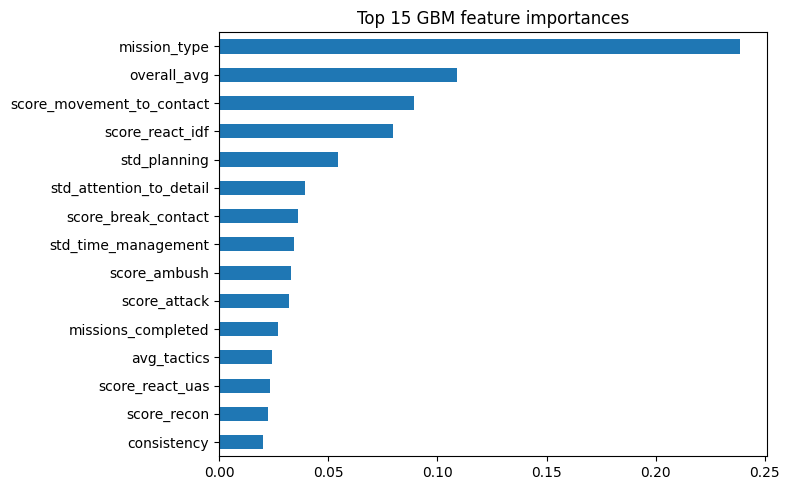

In [21]:
# Feature importances (matches fitted GBM in model.Athena)
scorer = athena.scorer
feat_imp = (
    pd.Series(scorer.model.feature_importances_, index=scorer.feature_cols)
    .sort_values(ascending=False)
)
from IPython.display import display

display(feat_imp.head(15).to_frame("importance"))

try:
    import matplotlib.pyplot as plt

    ax = feat_imp.head(15).sort_values().plot.barh(figsize=(8, 5), title="Top 15 GBM feature importances")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("Install matplotlib to plot importances.")

In-sample MAE on training rows: 0.2186 (1–5 scale)


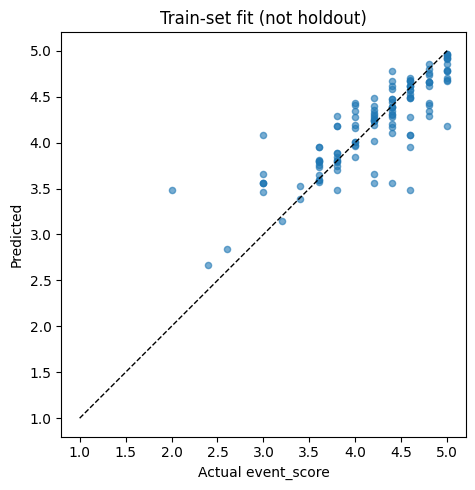

In [22]:
# In-sample predictions vs actual (training matrix — not a generalization test)
evals, details = load_data()
train_df = build_training_data(evals, athena.profiles)

X = scorer._prepare(train_df, fit=False)
y_true = train_df["event_score"].values
y_hat = np.clip(scorer.model.predict(X), 1.0, 5.0)

mae = float(np.mean(np.abs(y_true - y_hat)))
print(f"In-sample MAE on training rows: {mae:.4f} (1–5 scale)")

try:
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(5, 5))
    ax.scatter(y_true, y_hat, alpha=0.6, s=20)
    ax.plot([1, 5], [1, 5], "k--", lw=1)
    ax.set_xlabel("Actual event_score")
    ax.set_ylabel("Predicted")
    ax.set_title("Train-set fit (not holdout)")
    ax.set_aspect("equal", adjustable="box")
    plt.tight_layout()
    plt.show()
except ImportError:
    pass

In [23]:
# Demo: two distinct six-person options (default) + pool strengths/weaknesses
mission = "ambush"
top_k = 20
num_team_options = 2

result = athena.select_team(
    mission_type=mission,
    top_k=top_k,
    num_team_options=num_team_options,
)

from IPython.display import display

print("Mission:", mission, "| pool top_k:", top_k, "| num_team_options:", num_team_options)
print(
    "Each option is a different set of six people. Within an option, each person anchors a distinct "
    "task_group (see strength_role_label). Options are ranked by team_score; option 1 == result['team']."
)

for opt in result["team_options"]:
    print("\n--- Option", opt["option_id"], "| team_score:", opt["team_score"], "---")
    print("Greedy slot order (task_group picks 1→6):", " → ".join(opt["slot_order"]))
    team = opt["team"]
    role_by_id = {r["leader_identifier"]: r for r in (opt["breakdown"].get("strength_roles") or [])}
    team_show = team.assign(
        strength_role_key=team["leader_identifier"].map(
            lambda lid: role_by_id.get(lid, {}).get("role_key")
        ),
        strength_role_label=team["leader_identifier"].map(
            lambda lid: role_by_id.get(lid, {}).get("role_label")
        ),
    )
    display(
        team_show[
            [
                "leader_identifier",
                "leader_name",
                "leader_rank",
                "leader_unit",
                "strength_role_key",
                "strength_role_label",
                "raw_predicted_score",
                "predicted_score",
            ]
        ]
    )

cand = result["candidate_task_breakdowns"]
pool_summary = pd.DataFrame(
    {
        "pool_rank": [x["candidate_rank"] for x in cand],
        "leader_identifier": [x["leader_identifier"] for x in cand],
        "leader_name": [x["leader_name"] for x in cand],
        "predicted_score": [x["predicted_score"] for x in cand],
        "strengths (task_groups)": [", ".join(x["strengths_summary"]) for x in cand],
        "weaknesses (task_groups)": [", ".join(x["weaknesses_summary"]) for x in cand],
    }
)
display(pool_summary)


Mission: ambush | pool top_k: 20 | num_team_options: 2
Each option is a different set of six people. Within an option, each person anchors a distinct task_group (see strength_role_label). Options are ranked by team_score; option 1 == result['team'].

--- Option 1 | team_score: 5.844 ---
Greedy slot order (task_group picks 1→6): Planning → Decisiveness → Tactics → Time Management → Attention to Detail → ST&EO


,leader_identifier,leader_name,leader_rank,leader_unit,strength_role_key,strength_role_label,raw_predicted_score,predicted_score
0,Visgauss_A_3_3,Matthew Visgauss,SSG,A/3-172 IN,planning,Planning,4.2965,4.2965
1,Meyer_A_3_3,Rush Meyer,SSG,A/3-172 IN,decisiveness,Decisiveness,4.7551,4.7551
2,Sweet_A_1_4,Kyle Sweet,SSG,A/3-172 IN,tactics,Tactics,4.2458,4.2458
3,Rivas_A_3_2,Germaine Rivas,SGT,A/3-172 IN,time_management,Time Management,4.9193,4.9193
4,Carmondy_C_1_3,Shawn Carmody,SGT,C/3-172 IN,attention_to_detail,Attention to Detail,4.5278,4.5278
5,Mora_B_3_2,Joadel Mora,SSG,B/3-172 IN,st_eo,ST&EO,4.4356,4.4356



--- Option 2 | team_score: 5.6096 ---
Greedy slot order (task_group picks 1→6): Planning → Decisiveness → Attention to Detail → Tactics → Time Management → ST&EO


,leader_identifier,leader_name,leader_rank,leader_unit,strength_role_key,strength_role_label,raw_predicted_score,predicted_score
0,Visgauss_A_3_3,Matthew Visgauss,SSG,A/3-172 IN,planning,Planning,4.2965,4.2965
1,Meyer_A_3_3,Rush Meyer,SSG,A/3-172 IN,decisiveness,Decisiveness,4.7551,4.7551
2,Rivas_A_3_2,Germaine Rivas,SGT,A/3-172 IN,attention_to_detail,Attention to Detail,4.9193,4.9193
3,Sweet_A_1_4,Kyle Sweet,SSG,A/3-172 IN,tactics,Tactics,4.2458,4.2458
4,Kisswani_A_1_1,Ibrahim Kisswani,SSG,A/3-172 IN,time_management,Time Management,4.5677,4.5677
5,Mora_B_3_2,Joadel Mora,SSG,B/3-172 IN,st_eo,ST&EO,4.4356,4.4356


,pool_rank,leader_identifier,leader_name,predicted_score,strengths (task_groups),weaknesses (task_groups)
0,1,Rivas_A_3_2,Germaine Rivas,4.9193,"Time Management, Attention to Detail","ST&EO, Tactics"
1,2,Meyer_A_3_3,Rush Meyer,4.7551,"Decisiveness, Attention to Detail","Planning, ST&EO"
2,3,Harris_B_1_2,Joel Harris,4.7010,"Time Management, Attention to Detail","Planning, Decisiveness"
3,4,Nielson_C_3_2,Montgomery Nielson,4.6651,"Time Management, Decisiveness","ST&EO, Tactics"
4,5,Bleau_C_1_1,Shawn Bleau,4.6642,"Decisiveness, Time Management","Planning, ST&EO"
5,6,Kisswani_A_1_1,Ibrahim Kisswani,4.5677,"Decisiveness, Time Management","Planning, ST&EO"
6,7,Carmondy_C_1_3,Shawn Carmody,4.5278,"Attention to Detail, Time Management","ST&EO, Tactics"
7,8,Settele_C_2_1,Jack Settele,4.4854,"Planning, Tactics","Attention to Detail, Decisiveness"
8,9,Mora_B_3_2,Joadel Mora,4.4356,"Decisiveness, Tactics","Planning, Attention to Detail"
9,10,Spelter_B_2_2,Steven Spelter,4.4115,"Decisiveness, Time Management","Planning, Attention to Detail"
